# HDB Resale Price Prediction — Regression Model Comparison

**Prepared for:** Property Agent Company

**Dataset:** HDB Resale Flat Transactions (`data.csv`)

**Objective:** Predict resale price using structured HDB features and compare model accuracy across five regression algorithms:

- **Linear Regression**
- **Random Forest**
- **LightGBM**
- **XGBoost**
- **CatBoost**

---

## Step 1: Identify the Target Variable (y)

Define the variable to predict (the dependent variable).

In [2]:
TARGET_COLUMN = 'resale_price'  # Target column for HDB resale price prediction

---

## Step 2: Import Packages and Load Dataset

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Configure plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('fivethirtyeight')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All packages imported successfully!")

All packages imported successfully!


In [4]:
# Load your dataset
DATA_PATH = 'Consolidated Flat Transactions.csv'
#DATA_PATH = '../data.csv'

df = pd.read_csv(DATA_PATH)

# Preview the data
print(f"Dataset loaded with shape: {df.shape}")
df.head()

Dataset loaded with shape: (270619, 76)


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61,0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224,0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61,0,1.369092,103.839041,522.935557,Mayflower Secondary School,219,0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61,0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256,1,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61,0,1.369092,103.839041,424.046635,Mayflower Secondary School,219,0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61,0,1.369092,103.839041,322.732547,Mayflower Secondary School,219,0,1.368337,103.835439


---

## Step 3: Explore the Dataset Structure

Check the number of features, data types, and basic statistics.

In [5]:
# Check dimensions (rows, columns)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

# View column names and data types
print("\nColumn Info:")
print(df.info())

Dataset shape: (270619, 76)
Number of features: 76


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-null  object 
 8   lease_commence_date        270619 non-null  int64  
 9   resale_price               270619 non-null  float64
 10  Tranc_Year                 270619 non-null  int64  
 11  Tranc_Month                270619 non-null  int64  
 12  mid_storey          

In [6]:
# View basic statistics for numeric columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687589,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


In [7]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                       Missing Count  Missing %
Mall_Nearest_Distance           5210       1.93
Mall_Within_500m              168137      62.13
Mall_Within_1km                49132      18.16
Mall_Within_2km                 7036       2.60
Hawker_Within_500m            177013      65.41
Hawker_Within_1km             109046      40.30
Hawker_Within_2km              52516      19.41


---

## Step 3.5: Feature Engineering

Create new features help capture relationships that improve model performance.

In [8]:
# ========== FEATURE ENGINEERING SECTION ==========
# Add new engineered features below. Each feature is created from existing columns.


# Remaining Lease (Feature 1)
df['remaining_lease'] = 99 - df['hdb_age'] # Note: highly correlated with hdb_age

# Distance from CBD (in km) (Feature 2)
# Captures centrality premium using latitude and longitude
def haversine(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return radius_km * c

cbd_lat, cbd_lon = 1.2897, 103.8501
df['cbd_distance'] = haversine(df['Latitude'], df['Longitude'], cbd_lat, cbd_lon)

# Mature estate flag (1 = mature estate, 0 = non-mature estate) [Feature 3]
mature_estates = [
    'ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH',
    'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'KALLANG/WHAMPOA',
    'MARINE PARADE', 'PASIR RIS', 'QUEENSTOWN', 'SERANGOON',
    'TAMPINES', 'TOA PAYOH'
 ]
df['mature_estate'] = df['town'].str.upper().isin(mature_estates).astype(int)

# DBSS flag (1 = DBSS flat, 0 = non-DBSS) [Feature 4]
# Note: high multicollinearity expected with flat_model (which is in CATEGORICAL_FEATURES).
# Kept as an explicit flag since DBSS flats command a large price premium (~$773k median vs ~$473k overall).
df['is_dbss'] = df['flat_model'].fillna('').str.upper().str.contains('DBSS').astype(int)


# Liveability_index (5-pillar, includes secondary school) [Feature 5]

# --- Secondary school tier encoding ---
def sec_school_tier(row):
    year = row['Tranc_Year']
    cutoff = row['cutoff_point']

    if pd.isna(cutoff):
        return np.nan

    if year < 2021:
        return 'Tier 1' if cutoff >= 240 else 'Tier 2'

    return 'Tier 1' if cutoff <= 11 else 'Tier 2'

df['sec_school_tier'] = df.apply(sec_school_tier, axis=1)
tier_map = {'Tier 1': 1, 'Tier 2': 2}
df['school_tier_encoded'] = df['sec_school_tier'].map(tier_map)

# --- Primary school prestige index ---
branded_schools = [
    'NANYANG PRIMARY SCHOOL', 'TAO NAN SCHOOL', 'ROSYTH SCHOOL',
    'CATHOLIC HIGH SCHOOL', 'ST HILDAS PRIMARY SCHOOL',
    'HENRY PARK PRIMARY SCHOOL', 'AI TONG SCHOOL', 'RAFFLES GIRLS PRIMARY SCHOOL',
    'METHODIST GIRLS SCHOOL PRIMARY', 'ANGLO CHINESE SCHOOL PRIMARY',
    'SINGAPORE CHINESE GIRLS PRIMARY SCHOOL', 'CHIJ PRIMARY TOA PAYOH',
    'ST JOSEPHS INSTITUTION JUNIOR', 'CHIJ ST NICHOLAS GIRLS SCHOOL',
    'ST ANTHONYS PRIMARY SCHOOL', 'ST STEPHENS SCHOOL',
    'ANGLO CHINESE SCHOOL JUNIOR'
 ]

pri_distance = pd.to_numeric(df['pri_sch_nearest_distance'], errors='coerce')
pri_affiliation = pd.to_numeric(df['pri_sch_affiliation'], errors='coerce')

distance_conditions = [
    pri_distance <= 1000,
    (pri_distance > 1000) & (pri_distance <= 2000),
    pri_distance > 2000
 ]
distance_weights = [10, 5, 1]
df['dist_weight'] = np.select(distance_conditions, distance_weights, default=1)

clean_school_names = (
    df['pri_sch_name']
    .fillna('')
    .astype(str)
    .str.upper()
    .str.replace(r'[^A-Z0-9 ]', '', regex=True)
    .str.split()
    .str.join(' ')
 )

df['prestige_mult'] = np.where(
    clean_school_names.isin(branded_schools),
    2.0,
    np.where(pri_affiliation == 1, 1.5, 1.0)
 )
df['primary_school_prestige_index'] = df['dist_weight'] * df['prestige_mult']

# --- Liveability index (5-pillar, includes secondary school) ---
def minmax(series):
    series_min = series.min()
    series_max = series.max()
    if pd.isna(series_min) or pd.isna(series_max) or series_max == series_min:
        return pd.Series(0.0, index=series.index)
    return (series - series_min) / (series_max - series_min)

df['live_pri'] = minmax(df['primary_school_prestige_index'])

sec_prox = minmax(df['sec_sch_nearest_dist'].max() - df['sec_sch_nearest_dist'])
sec_qual = (2 - df['school_tier_encoded']) / 1.0
df['live_sec'] = 0.5 * sec_prox + 0.5 * sec_qual

mrt_prox = minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
mrt_inter = pd.to_numeric(df['mrt_interchange'], errors='coerce').fillna(0).clip(0, 1)
df['live_mrt'] = 0.7 * mrt_prox + 0.3 * mrt_inter

hawker_prox = minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
hawker_stalls = minmax(df['hawker_food_stalls'])
df['live_hawker'] = 0.6 * hawker_prox + 0.4 * hawker_stalls

mall_prox = minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
mall_count = minmax(df['Mall_Within_2km'].fillna(0))
df['live_mall'] = 0.5 * mall_prox + 0.5 * mall_count

df['liveability_index'] = (
    0.20 * df['live_pri']
    + 0.20 * df['live_sec']
    + 0.25 * df['live_mrt']
    + 0.15 * df['live_hawker']
    + 0.20 * df['live_mall']
 )

# Display the newly created columns
new_columns = ['remaining_lease', 'cbd_distance', 'mature_estate', 'is_dbss', 'liveability_index']
print("\nEngineered Features Created:")
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print(f"\nDataset now has {df.shape[1]} columns")
df.head()



Engineered Features Created:
  - remaining_lease: min=40.00, max=96.00, mean=68.86
  - cbd_distance: min=0.69, max=19.58, mean=11.97
  - mature_estate: min=0.00, max=1.00, mean=0.43
  - is_dbss: min=0.00, max=1.00, mean=0.01
  - liveability_index: min=0.11, max=0.83, mean=0.53

Dataset now has 91 columns


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,school_tier_encoded,dist_weight,prestige_mult,primary_school_prestige_index,live_pri,live_sec,live_mrt,live_hawker,live_mall,liveability_index
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,2,10,1.0,10.0,0.473684,0.439463,0.472386,0.610528,0.416383,0.475582
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,2,10,1.0,10.0,0.473684,0.432776,0.466963,0.622549,0.416129,0.474641
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,1,10,1.0,10.0,0.473684,0.950069,0.440366,0.632881,0.389874,0.567749
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,2,10,1.0,10.0,0.473684,0.446510,0.442974,0.619883,0.398621,0.467489
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,2,10,1.0,10.0,0.473684,0.460581,0.426929,0.564708,0.396753,0.457642


---

## Step 4: Select Features for Modeling

Choose relevant features based on domain knowledge and exploratory analysis.

In [9]:
# ========== MODIFY THIS ==========
# Define feature columns (numeric and categorical)

# Numeric features that likely influence resale price
NUMERIC_FEATURES = [
    'floor_area_sqm',
    'Tranc_Year',
    'max_floor_lvl',
    'mid_storey',
    
]

# Engineered features (created in Step 3.5)
# Remove 'liveability_nocut_4pillar' here as well if you later delete the Step 3.5B cell.
# Note: liveability_index (Step 3.5A) is kept as a reference cell but is excluded from this list.
ENGINEERED_FEATURES = [
        'liveability_index',      # optional 5-pillar liveability index (includes secondary school)
    'remaining_lease',
    'is_dbss',           # binary DBSS flag; expect high correlation with flat_model
    'mature_estate',
    'cbd_distance',
        ]

# Categorical features
CATEGORICAL_FEATURES = [
    'flat_type',
    'flat_model',
]

# All features combined (numeric + engineered + categorical)
ALL_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + CATEGORICAL_FEATURES
# =================================

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"\nTotal features: {len(ALL_FEATURES)}")


Numeric features (4): ['floor_area_sqm', 'Tranc_Year', 'max_floor_lvl', 'mid_storey']

Engineered features (5): ['liveability_index', 'remaining_lease', 'is_dbss', 'mature_estate', 'cbd_distance']

Categorical features (2): ['flat_type', 'flat_model']

Total features: 11


---

## Step 5: Analyze Feature Correlations

Visualize correlations between numeric features (including engineered features) and the target variable.

In [10]:
# Correlation matrix for numeric features + engineered features + target
corr_cols = NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]
correlation_matrix = df[corr_cols].corr()

# Show correlations with target variable, sorted by strength
print("Correlations with Target Variable:")
print(correlation_matrix[TARGET_COLUMN].sort_values(ascending=False))

Correlations with Target Variable:
resale_price         1.000000
floor_area_sqm       0.584071
max_floor_lvl        0.474855
remaining_lease      0.400101
mid_storey           0.345751
Tranc_Year           0.338276
is_dbss              0.184388
mature_estate        0.164892
liveability_index    0.154447
cbd_distance        -0.202455
Name: resale_price, dtype: float64


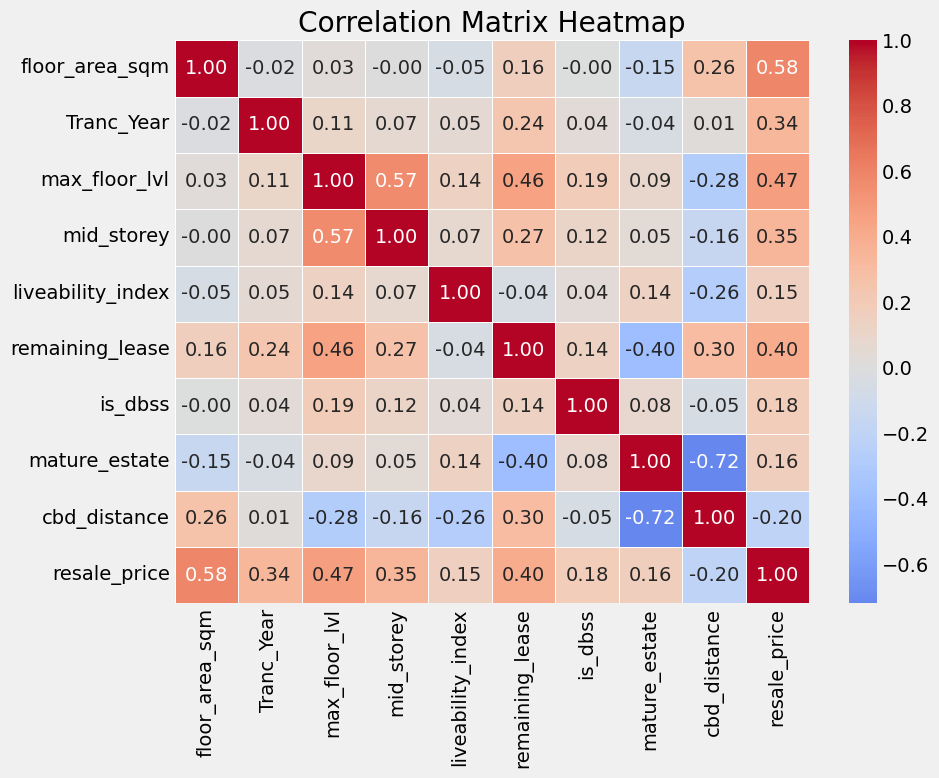

In [11]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, center=0)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [12]:
# Check for highly correlated features (multicollinearity)
# This helps identify features that may be redundant

CORRELATION_THRESHOLD = 0.7  # Features with correlation above this may cause issues

# Get correlation matrix without target
feature_corr = df[NUMERIC_FEATURES + ENGINEERED_FEATURES].corr()

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = abs(feature_corr.iloc[i, j])
        if corr_val > CORRELATION_THRESHOLD:
            high_corr_pairs.append({
                'Feature 1': feature_corr.columns[i],
                'Feature 2': feature_corr.columns[j],
                'Correlation': feature_corr.iloc[i, j]
            })

if high_corr_pairs:
    print(f"⚠️ Highly Correlated Feature Pairs (|r| > {CORRELATION_THRESHOLD}):")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\nConsider removing one feature from each pair to reduce multicollinearity.")
else:
    print(f"✓ No feature pairs have correlation above {CORRELATION_THRESHOLD}")


⚠️ Highly Correlated Feature Pairs (|r| > 0.7):
    Feature 1    Feature 2  Correlation
mature_estate cbd_distance    -0.718821

Consider removing one feature from each pair to reduce multicollinearity.


Note: If final model is not based on Linear Regression, multicollinearity does not affect the model accuracy of the other models and we can keep both correlated variables within the model .

---

## Step 6: Prepare Data for Modeling

Handle missing values and encode categorical variables.

Two encoding strategies are used:
- **Label Encoding** -> for tree models (Random Forest, LightGBM, XGBoost, CatBoost)
- **One-Hot Encoding** -> for Linear Regression (avoids fake numeric ordering of categories)

### 6a. Drop Missing Values

In [13]:
# Create a copy of the dataframe with selected features
model_df = df[ALL_FEATURES + [TARGET_COLUMN]].copy()

# Drop rows with missing values in selected columns
initial_rows = len(model_df)
model_df = model_df.dropna()
rows_dropped = initial_rows - len(model_df)
pct_dropped = rows_dropped / initial_rows * 100
print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after cleaning:  {len(model_df)}")
print(f"Rows dropped:         {rows_dropped} ({pct_dropped:.1f}%)")

Rows before cleaning: 270619
Rows after cleaning:  265409
Rows dropped:         5210 (1.9%)


In [14]:
# ===== 6b. LABEL ENCODING — for tree models =====
# Tree-based models can handle integer-encoded categoricals efficiently

label_encoders = {}
model_df_encoded = model_df.copy()

if CATEGORICAL_FEATURES:
    for col in CATEGORICAL_FEATURES:
        le = LabelEncoder()
        model_df_encoded[col] = le.fit_transform(model_df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"Label encoded: {col} ({len(le.classes_)} unique values)")
else:
    print("No categorical features to label encode.")

print(f"\nmodel_df_encoded shape: {model_df_encoded.shape}")

# ===== 6c. ONE-HOT ENCODING — for Linear Regression =====
# Linear regression requires proper encoding to avoid treating categories as ordered numbers

model_df_ohe = model_df[NUMERIC_FEATURES + ENGINEERED_FEATURES + [TARGET_COLUMN]].copy()

if CATEGORICAL_FEATURES:
    ohe_dummies = pd.get_dummies(model_df[CATEGORICAL_FEATURES], drop_first=True)
    model_df_ohe = pd.concat([
        model_df_ohe.reset_index(drop=True),
        ohe_dummies.reset_index(drop=True)
    ], axis=1)
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES + list(ohe_dummies.columns)
    print(f"\nOne-hot encoded: {len(ohe_dummies.columns)} dummy columns from {len(CATEGORICAL_FEATURES)} categorical features")
else:
    OHE_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES
    print("\nNo categorical features to one-hot encode.")

print(f"Total features for Linear Regression: {len(OHE_FEATURES)}")
print(f"model_df_ohe shape: {model_df_ohe.shape}")

Label encoded: flat_type (7 unique values)
Label encoded: flat_model (21 unique values)

model_df_encoded shape: (265409, 12)

One-hot encoded: 26 dummy columns from 2 categorical features
Total features for Linear Regression: 35
model_df_ohe shape: (265409, 36)


---

## Step 7: Split Data into Train and Test Sets

In [15]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
# =================================

# --- Tree models: label-encoded features ---
X = model_df_encoded[ALL_FEATURES]
y = model_df_encoded[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# --- Linear Regression: one-hot encoded features ---
X_lr = model_df_ohe[OHE_FEATURES]
y_lr = model_df_ohe[TARGET_COLUMN]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {len(X_train)} ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set size:     {len(X_test)} ({100*TEST_SIZE:.0f}%)")
print(f"\nTree model features:             {len(ALL_FEATURES)}")
print(f"Linear Regression features (OHE): {len(OHE_FEATURES)}")

Training set size: 199056 (75%)
Test set size:     66353 (25%)

Tree model features:             11
Linear Regression features (OHE): 35


---

## Step 8: Define Model Evaluation Function

Create a reusable function to train models and calculate key metrics.

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train a model and return evaluation metrics.
    
    Parameters:
    -----------
    model : estimator object
        The model to train and evaluate
    X_train, X_test : DataFrames
        Training and test features
    y_train, y_test : Series
        Training and test targets
    model_name : str
        Name for display purposes
        
    Returns:
    --------
    dict : Dictionary containing model metrics
    """
    # Fit the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_r2 = metrics.r2_score(y_train, y_train_pred)
    test_r2 = metrics.r2_score(y_test, y_test_pred)
    results = {
        'Model': model_name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'discrepancy': abs(train_r2 - test_r2),
        'Train RMSE': np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)),
        'fitted_model': model,
        'y_test_pred': y_test_pred
    }
    
    return results

def display_results(results):
    """Display formatted results for a single model."""
    print("=" * 50)
    print(f"MODEL: {results['Model']}")
    print("=" * 50)
    print(f"Train R² Score: {results['Train R²']:.4f}")
    print(f"Test R² Score:  {results['Test R²']:.4f}")
    print(f"R² Discrepancy: {results['discrepancy']:.4f}")
    print()
    print(f"Train RMSE: ${results['Train RMSE']:,.2f}")
    print(f"Test RMSE:  ${results['Test RMSE']:,.2f}")
    print()
  

---

## Step 9: Train and Evaluate Linear Regression Model

Linear Regression is a baseline model that predicts resale price by fitting a straight-line relationship between features and target.

In [30]:
# ========== LINEAR REGRESSION  ==========
# Uses one-hot encoded features (X_train_lr / X_test_lr)
# to avoid treating categorical labels as ordered numbers

lr_model = LinearRegression()

# Train and evaluate
lr_results = evaluate_model(lr_model, X_train_lr, X_test_lr, y_train_lr, y_test_lr, 'Linear Regression')
display_results(lr_results)

MODEL: Linear Regression
Train R² Score: 0.7897
Test R² Score:  0.7881
R² Discrepancy: 0.0016

Train RMSE: $80,399.58
Test RMSE:  $80,286.62



In [18]:
# Display Linear Regression coefficients
# Uses OHE_FEATURES (one-hot encoded column names) to correctly label each dummy column
lr_coef_df = pd.DataFrame({
    'Feature': OHE_FEATURES,
    'Coefficient': lr_results['fitted_model'].coef_}).sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Coefficients:")
print(f"Intercept: {lr_results['fitted_model'].intercept_:,.2f}")
print(f"\nTop 20 Feature Coefficients (by magnitude):")
print(lr_coef_df.head(20).to_string(index=False))

Linear Regression Coefficients:
Intercept: -23,819,089.25

Top 20 Feature Coefficients (by magnitude):
                          Feature   Coefficient
               flat_model_Terrace 382664.235392
                liveability_index 193866.444551
               flat_model_Type S2 185562.072258
   flat_model_Improved-Maisonette 182408.570275
flat_model_Premium Apartment Loft 147261.630360
               flat_model_Type S1 133846.575544
    flat_model_Model A-Maisonette 110884.284495
    flat_model_Premium Maisonette  91819.080067
            flat_model_Maisonette  82911.051444
         flat_model_Adjoined flat  77954.031255
       flat_type_MULTI-GENERATION  65050.274088
      flat_model_Multi Generation  65050.274088
                    mature_estate  63266.779816
                  flat_model_DBSS  49937.156789
                          is_dbss  49937.156789
            flat_model_Simplified  38079.437715
                 flat_type_2 ROOM -34449.089685
                  flat_model_3Gen

---

## Step 10: Train and Evaluate Random Forest Model

Random Forest averages many decision trees to capture non-linear patterns while reducing overfitting.

In [31]:
# ========== RANDOM FOREST ==========
# Hyperparameters (modify as needed)
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=15,              # Maximum depth of trees
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2,        # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    n_jobs=-1                  # Use all CPU cores
)

# Train and evaluate
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')
display_results(rf_results)

MODEL: Random Forest
Train R² Score: 0.9719
Test R² Score:  0.9605
R² Discrepancy: 0.0115

Train RMSE: $29,365.72
Test RMSE:  $34,668.84



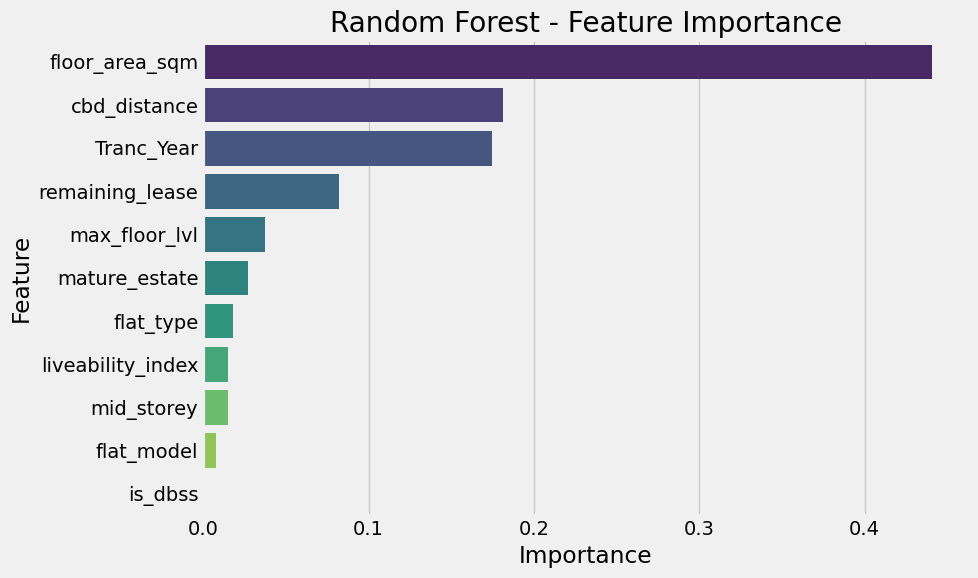

Feature Importance:
          Feature  Importance
   floor_area_sqm    0.440572
     cbd_distance    0.181074
       Tranc_Year    0.174412
  remaining_lease    0.082443
    max_floor_lvl    0.037697
    mature_estate    0.027234
        flat_type    0.017817
liveability_index    0.015175
       mid_storey    0.014844
       flat_model    0.007985
          is_dbss    0.000747


In [20]:
# Feature importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': rf_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(rf_importance.to_string(index=False))

---

## Step 11: Train and Evaluate LightGBM Model

LightGBM is a fast gradient-boosting tree model optimized for efficient training on large tabular datasets.

In [32]:
# ========== LIGHTGBM ==========
# Hyperparameters (modify as needed)
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=15,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    num_leaves=31,             # Maximum number of leaves in one tree
    min_child_samples=20,      # Minimum samples in a leaf
    random_state=RANDOM_STATE,
    verbose=-1                 # Suppress output
)

# Train and evaluate
lgbm_results = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test, 'LightGBM')
display_results(lgbm_results)

MODEL: LightGBM
Train R² Score: 0.9525
Test R² Score:  0.9513
R² Discrepancy: 0.0013

Train RMSE: $38,203.18
Test RMSE:  $38,508.13



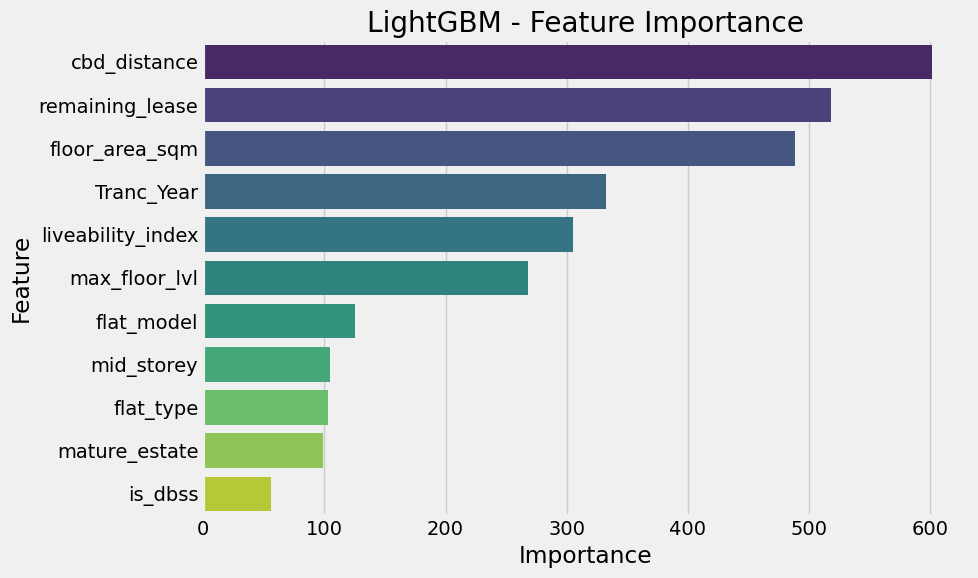

Feature Importance:
          Feature  Importance
     cbd_distance         601
  remaining_lease         518
   floor_area_sqm         488
       Tranc_Year         332
liveability_index         305
    max_floor_lvl         268
       flat_model         125
       mid_storey         105
        flat_type         103
    mature_estate          99
          is_dbss          56


In [22]:
# Feature importance for LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': lgbm_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=lgbm_importance, x='Importance', y='Feature', palette='viridis')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(lgbm_importance.to_string(index=False))

---

## Step 12: Train and Evaluate XGBoost Model

XGBoost is a regularized boosting algorithm that improves predictions by sequentially correcting prior errors.

In [33]:
# ========== XGBOOST ==========
# Hyperparameters (modify as needed)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,          # Number of boosting rounds
    max_depth=10,              # Maximum depth of trees
    learning_rate=0.1,         # Learning rate
    min_child_weight=5,        # Minimum sum of instance weight in a child
    subsample=0.8,             # Subsample ratio of training instances
    colsample_bytree=0.8,      # Subsample ratio of columns
    random_state=RANDOM_STATE,
    verbosity=0                # Suppress output
)

# Train and evaluate
xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')
display_results(xgb_results)

MODEL: XGBoost
Train R² Score: 0.9777
Test R² Score:  0.9711
R² Discrepancy: 0.0066

Train RMSE: $26,206.22
Test RMSE:  $29,671.56



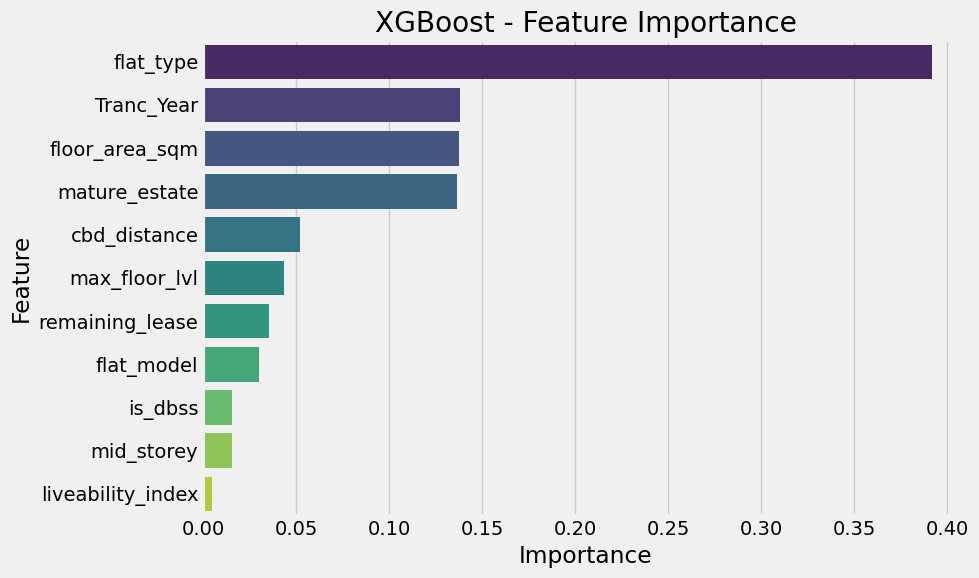

Feature Importance:
          Feature  Importance
        flat_type    0.391527
       Tranc_Year    0.137918
   floor_area_sqm    0.137539
    mature_estate    0.136518
     cbd_distance    0.051865
    max_floor_lvl    0.043506
  remaining_lease    0.035265
       flat_model    0.029856
          is_dbss    0.015613
       mid_storey    0.015603
liveability_index    0.004789


In [24]:
# Feature importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': xgb_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(xgb_importance.to_string(index=False))

---

## Step 13: Train and Evaluate CatBoost Model

CatBoost is a boosting model designed to handle categorical features effectively with minimal preprocessing.

In [34]:
# ========== CATBOOST ==========
# Hyperparameters (modify as needed)
catboost_model = CatBoostRegressor(
    iterations=100,            # Number of boosting iterations
    depth=10,                  # Depth of the tree
    learning_rate=0.1,         # Learning rate
    l2_leaf_reg=3,             # L2 regularization coefficient
    random_state=RANDOM_STATE,
    verbose=0                  # Suppress output
)

# Train and evaluate
catboost_results = evaluate_model(catboost_model, X_train, X_test, y_train, y_test, 'CatBoost')
display_results(catboost_results)

MODEL: CatBoost
Train R² Score: 0.9540
Test R² Score:  0.9529
R² Discrepancy: 0.0011

Train RMSE: $37,586.56
Test RMSE:  $37,846.19



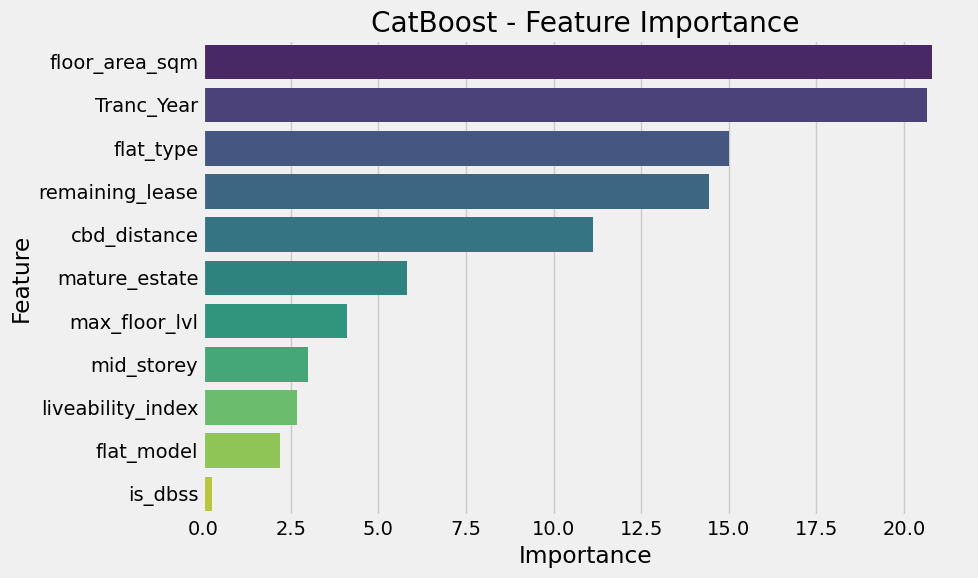

Feature Importance:
          Feature  Importance
   floor_area_sqm   20.787023
       Tranc_Year   20.642098
        flat_type   15.013837
  remaining_lease   14.421731
     cbd_distance   11.122562
    mature_estate    5.822116
    max_floor_lvl    4.098839
       mid_storey    2.986590
liveability_index    2.667980
       flat_model    2.196480
          is_dbss    0.240744


In [26]:
# Feature importance for CatBoost
catboost_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': catboost_results['fitted_model'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=catboost_importance, x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost - Feature Importance')
plt.tight_layout()
plt.show()

print("Feature Importance:")
print(catboost_importance.to_string(index=False))

---

## Step 14: Model Comparison Summary Table

Compare the performance of all five models side-by-side.

In [27]:
# Collect results from all models (including Linear Regression baseline)
all_results = [lr_results, rf_results, lgbm_results, xgb_results, catboost_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Train R²': round(r['Train R²'], 4),
        'Test R²': round(r['Test R²'], 4),
        'discrepancy': round(r['discrepancy'], 4),
        'Train RMSE': round(r['Train RMSE'], 2),
        'Test RMSE': round(r['Test RMSE'], 2)
    }
    for r in all_results
])

# Sort by Test R² (best performance first)
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON SUMMARY (5 Models)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)



MODEL COMPARISON SUMMARY (5 Models)
            Model  Train R²  Test R²  discrepancy  Train RMSE  Test RMSE
          XGBoost    0.9777   0.9711       0.0066    26206.22   29671.56
    Random Forest    0.9719   0.9605       0.0115    29365.72   34668.84
         CatBoost    0.9540   0.9529       0.0011    37586.56   37846.19
         LightGBM    0.9525   0.9513       0.0013    38203.18   38508.13
Linear Regression    0.7897   0.7881       0.0016    80399.58   80286.62



In [28]:
# Save a CSV with a fixed model order (independent of cell 42 display sorting)
# export_order = ['Linear Regression', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']

# comparison_df_export = comparison_df.copy()
# comparison_df_export['Model'] = pd.Categorical(
#     comparison_df_export['Model'],
#     categories=export_order,
#     ordered=True
# )
# comparison_df_export = comparison_df_export.sort_values('Model').reset_index(drop=True)

# comparison_df_export.to_csv('model_comparison_results.csv', index=False)
# print("Saved model_comparison_results.csv with model order:")
# print("Linear Regression -> Random Forest -> LightGBM -> XGBoost -> CatBoost")

## Step 15: Model Selection

Compare all five models to select final model based on train-test scores and run time

-Refer to google sheet tracker (https://tinyurl.com/23han76b) and/or ppt presentation slides for listing of all models and variables
 
-Final model selected: LightGBM, due to lowest train-test discrepancy and run time

## Step 16: Export Model for Web App Development

In [29]:
# ========== EXPORT MODEL AND ARTEFACTS TO WEB APP ==========
# Run this cell after training to update app/models/ with the latest model.
# The web app (app/app.py) reads these files at startup.
# import joblib
# import json
# from pathlib import Path

# MODEL_DIR = Path("../app/models")
# MODEL_DIR.mkdir(exist_ok=True)

# # 1. Save trained LightGBM model (selected model — lowest train/test discrepancy)
# joblib.dump(lgbm_results["fitted_model"], MODEL_DIR / "lgbm_regressor.joblib")
# print("Saved: lgbm_regressor.joblib")

# # 2. Save feature column list used during training
# with open(MODEL_DIR / "feature_columns.json", "w") as f:
#     json.dump(ALL_FEATURES, f)
# print(f"Saved: feature_columns.json  ({len(ALL_FEATURES)} features: {ALL_FEATURES})")

# # 3. Save feature medians as fallback values for inputs not provided by the user
# medians = model_df_encoded[ALL_FEATURES].median().to_dict()
# with open(MODEL_DIR / "feature_medians.json", "w") as f:
#     json.dump(medians, f, indent=2)
# print("Saved: feature_medians.json")

# # 4. Save label encoder classes so the web app can encode user-selected values
# label_classes = {col: le.classes_.tolist() for col, le in label_encoders.items()}
# with open(MODEL_DIR / "label_classes.json", "w") as f:
#     json.dump(label_classes, f, indent=2)
# print("Saved: label_classes.json")
# for col, classes in label_classes.items():
#     print(f"  {col}: {classes}")